![Portada de la actividad](image.png)

# ESCUELA DE INGENIERÍA

## Machine Learning

**Unidad 1**

Integrantes: Camila Donoso Araya

# Introducción

En este trabajo se analizó la base de datos train.csv de la base de datos dada Store Sales: Time Series Forecasting de Kaggle, la cual contiene información histórica de ventas de la cadena Corporación Favorita en Ecuador. Este conjunto de datos integra registros de múltiples familias de productos a lo largo del tiempo, lo que hace que el estudio global sea más complejo. A partir del análisis exploratorio se verificó que la base de datos no presenta valores perdidos, lo cual representa una ventaja metodológica importante, pues evita la aplicación de técnicas de imputación y permite conservar la estructura original de la información. Asimismo, por tratarse de una serie temporal, la separación de los datos no se realizó de manera aleatoria, sino respetando el orden cronológico, lo que añade un grado extra de dificultad al proceso analítico y de modelado. En este contexto, la serie temporal quedó conformada por un total de 1684 observaciones, las cuales se dividieron en 1178 para entrenamiento, 337 para validación y 169 para test; además, los datos fueron sometidos previamente a un proceso de winsorización y posteriormente a una transformación Box-Cox, con el propósito de reducir la influencia de valores extremos y estabilizar la variabilidad de la serie, dejando así los datos adecuadamente preparados para las siguientes etapas del proceso.

1) Realiza una presentación de diferentes Framework para poder aplicar analítica de datos:

| Framework                | Descripción                                 | Limitaciones                                             | Alcances                                       |
| ------------------------ | ------------------------------------------- | -------------------------------------------------------- | ---------------------------------------------- |
| **Pandas**               | Manipulación y limpieza de datos tabulares. | No entrena modelos complejos.                            | Exploración, limpieza y preparación de datos.  |
| **NumPy**                | Cálculo numérico y manejo de arreglos.      | Poco amigable para tablas.                               | Base matemática para el análisis.              |
| **Scikit-learn**         | Machine learning clásico y evaluación.      | Limitado en deep learning y series temporales avanzadas. | Pipelines, splits, métricas y modelos base.    |
| **Statsmodels**          | Modelado estadístico y series de tiempo.    | Menos flexible para pipelines modernos.                  | Análisis e interpretación de datos temporales. |
| **Matplotlib / Seaborn** | Visualización de datos.                     | No modelan ni predicen.                                  | Gráficos, patrones, tendencias y outliers.     |


2) Calidad del datos:

    a. Realiza una exploración de los datos, explícalos.

    Elegimos el dataset llamado Store Sales - Time Series Forecasting de Kaggle.

    La base de datos train.csv corresponde al conjunto de entrenamiento del problema, su objetivo es predecir las ventas de distintas familias de productos en varias tiendas de la cadena Favorita, en Ecuador. El archivo contiene información histórica de ventas junto con variables explicativas como la fecha, la tienda, la familia del producto y el número de promociones activas.

    * Variable dependiente:

    sales: representa las ventas observadas de una familia de productos en una tienda específica y en una fecha determinada.
    Tipo de dato: decimal.

    * Variables independientes:

    id: identificador único de cada registro.
    Tipo de dato: entero.

    date: fecha de la observación.
    Tipo de dato: fecha.

    store_nbr: número o identificador de la tienda.
    Tipo de dato: entero.

    family: familia o categoría del producto, por ejemplo POULTRY, PRODUCE o PREPARED FOODS.
    Tipo de dato: texto.

    onpromotion: cantidad de ítems de esa familia que estaban en promoción en esa tienda y fecha.
    Tipo de dato: entero.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df["date"] = pd.to_datetime(df["date"])

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print(df.head())
print(df.dtypes)

print("Fecha inicial:", df["date"].min().date())
print("Fecha final:", df["date"].max().date())

print("Valores faltantes por columna:")
print(df.isnull().sum())

Filas: 3000888
Columnas: 6
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object
Fecha inicial: 2013-01-01
Fecha final: 2017-08-15
Valores faltantes por columna:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


Como podemos observar, la base de datos tiene 3.000.888 registros, y no se presentan valores perdidos en ninguna de las columnas. Además, el período de tiempo del dataset comprende desde 2013-01-01 hasta 2017-08-15.

In [3]:
print("Resumen estadístico de variables numéricas:")
print(df[["sales", "onpromotion"]].describe())

print("Número de tiendas:", df["store_nbr"].nunique())
print("Número de familias de productos:", df["family"].nunique())

print("Primeras 10 familias de productos:")
print(list(df["family"].unique()[:10]))

Resumen estadístico de variables numéricas:
              sales   onpromotion
count  3.000888e+06  3.000888e+06
mean   3.577757e+02  2.602770e+00
std    1.101998e+03  1.221888e+01
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    1.100000e+01  0.000000e+00
75%    1.958473e+02  0.000000e+00
max    1.247170e+05  7.410000e+02
Número de tiendas: 54
Número de familias de productos: 33
Primeras 10 familias de productos:
['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI']


Las variables numéricas nos muestran una alta dispersión, especialmente en sales, lo que sugiere la presencia de valores extremos. Además, el dataset contiene información de 54 tiendas y 33 familias de productos, lo que evidencia una base amplia y diversa para el análisis.

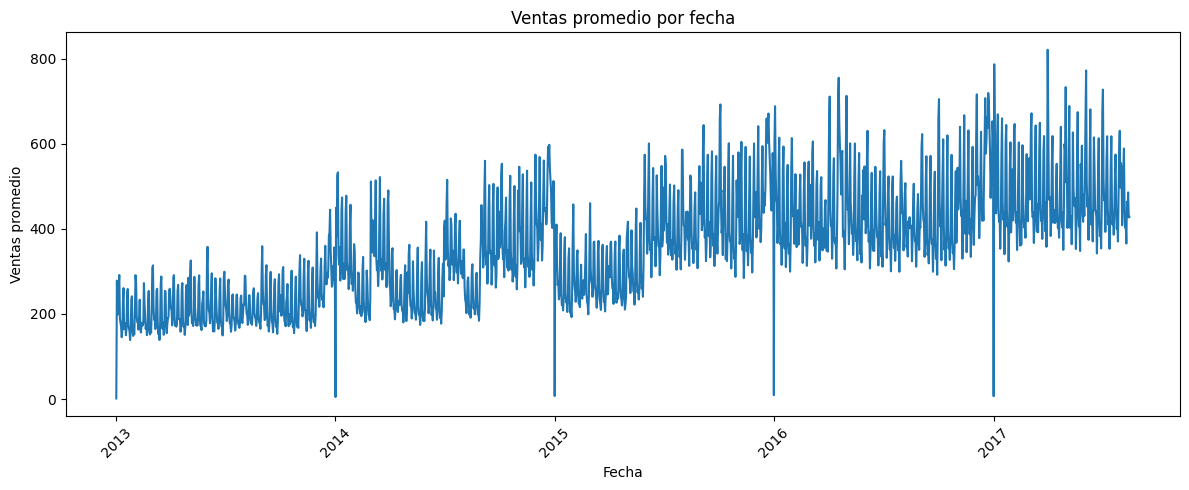

In [4]:
ventas_por_fecha = df.groupby("date")["sales"].mean()

plt.figure(figsize=(12,5))
plt.plot(ventas_por_fecha.index, ventas_por_fecha.values)
plt.title("Ventas promedio por fecha")
plt.xlabel("Fecha")
plt.ylabel("Ventas promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La gráfica muestra la evolución de las ventas promedio, podemos observar que existe una tendencia creciente a lo largo del tiempo, aunque con fluctuaciones marcadas y caídas puntuales en el fin del año. 

<Figure size 1000x500 with 0 Axes>

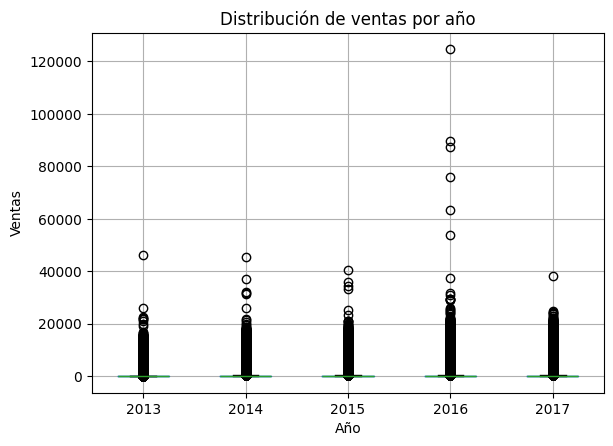

In [6]:
df["date"] = pd.to_datetime(df["date"])
df["anio"] = df["date"].dt.year

plt.figure(figsize=(10,5))
df.boxplot(column="sales", by="anio")
plt.title("Distribución de ventas por año")
plt.suptitle("")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.show()

Como podemos observar la mayor parte de las ventas se concentra en valores bajos o moderados, mientras que existe un número importante de observaciones con ventas altas, esto nos genera una distribucion muy asímetrica.

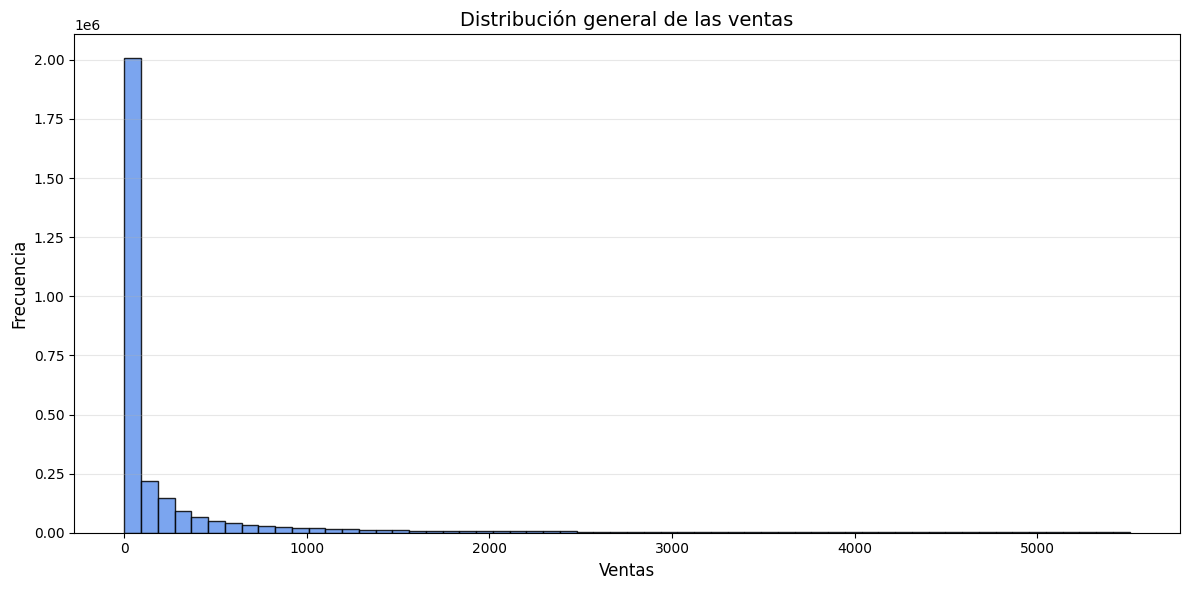

In [ ]:
#########################
datos = df["sales"]
datos = datos[datos <= datos.quantile(0.99)]

plt.figure(figsize=(12,6))
plt.hist(datos, bins=60, color="cornflowerblue", edgecolor="black", alpha=0.85)
plt.title("Distribución general de las ventas", fontsize=14)
plt.xlabel("Ventas", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
 

El histograma nos muestra que la mayor parte de las observaciones se concentra en ventas bajas, lo cual resulta coherente con el comportamiento habitual de compra, ya que es más común que los clientes adquieran pocas unidades de un producto que grandes cantidades.

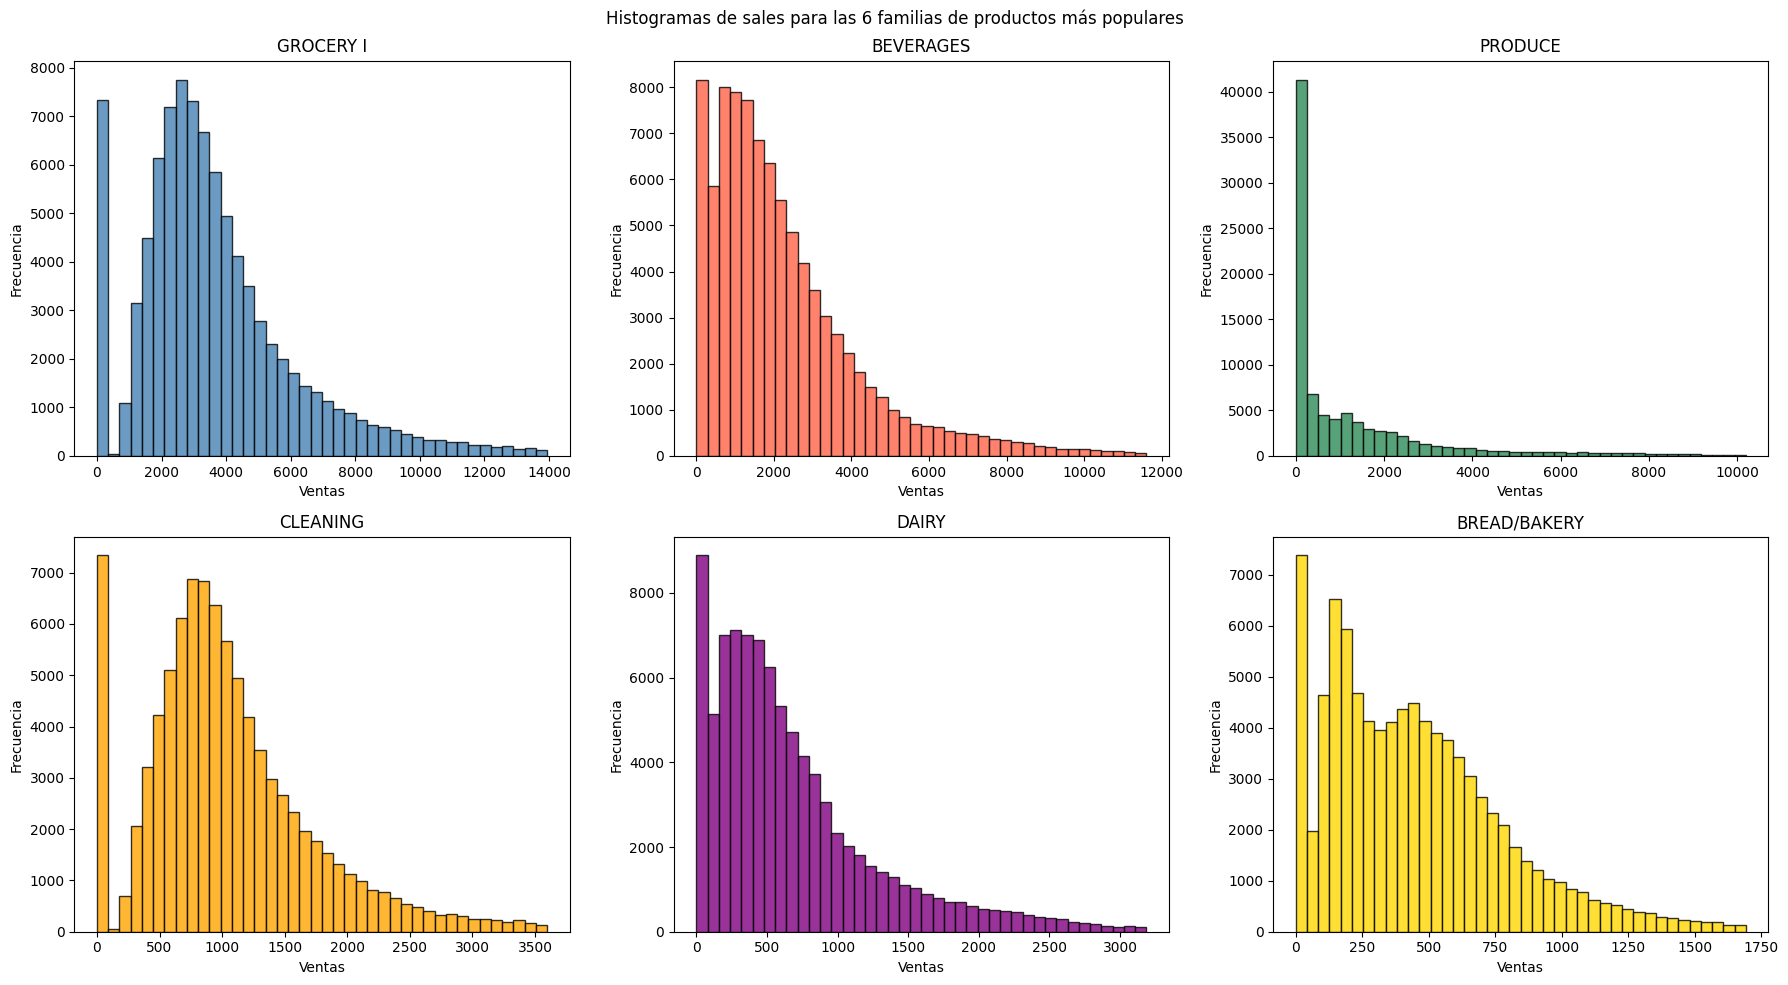

In [26]:
########################################################

top_6 = df.groupby("family")["sales"].sum().nlargest(6).index
colores = ["steelblue", "tomato", "seagreen", "orange", "purple", "gold"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, familia in enumerate(top_6):
    datos = df[df["family"] == familia]["sales"]
    datos = datos[datos <= datos.quantile(0.99)]
    axes[i].hist(datos, bins=40, color=colores[i], edgecolor="black", alpha=0.8)
    axes[i].set_title(familia)
    axes[i].set_xlabel("Ventas")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Histogramas de sales para las 6 familias de productos más populares")
plt.tight_layout()
plt.show()

Podemos observar que, en general, las seis categorías presentan una distribución sesgada a la derecha, en la que predominan las ventas bajas y medias, mientras que las ventas muy altas son menos frecuentes. Esto indica un comportamiento similar entre las categorías más vendidas, aunque con distintas escalas de volumen. Además, resulta interesante notar que la mayor frecuencia se concentra en una sola unidad vendida, la cual no es seguida por dos unidades vendidas, como podría esperarse intuitivamente.

Correlación entre sales y onpromotion: 0.4279


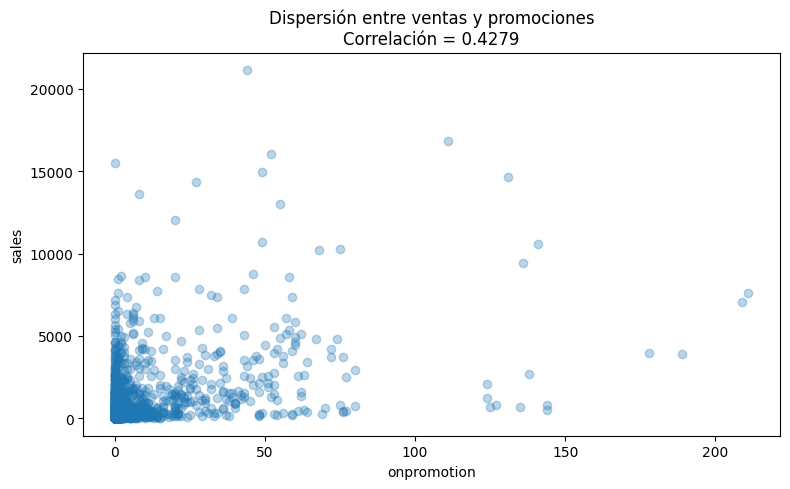

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Correlación
correlacion = df["sales"].corr(df["onpromotion"])
print(f"Correlación entre sales y onpromotion: {correlacion:.4f}")

# Tomar una muestra para que el gráfico sea legible
muestra = df.sample(5000, random_state=42)

# Gráfico de dispersión
plt.figure(figsize=(8,5))
plt.scatter(muestra["onpromotion"], muestra["sales"], alpha=0.3)
plt.title(f"Dispersión entre ventas y promociones\nCorrelación = {correlacion:.4f}")
plt.xlabel("onpromotion")
plt.ylabel("sales")
plt.tight_layout()
plt.show()

En este gráfico de dispersión no se muestra una relacion fuerte como se esperaba entre sales y onpromotion, aunque el coeficiente de correlación es positivo, la dispersión de los datos es muy alta, por lo que la cantidad de primociones por sí sola no parece explicar de manera suficiente el comportamiento de las ventas.

## b. Realiza una limpieza de datos.

    i. Identificación y tratamiento de datos atípicos.

Q1: 248.43517763040123
Q3: 441.04684734370085
IQR: 192.61166971329962
Límite inferior: 0
Límite superior: 729.9643519136503
Cantidad de outliers detectados: 5


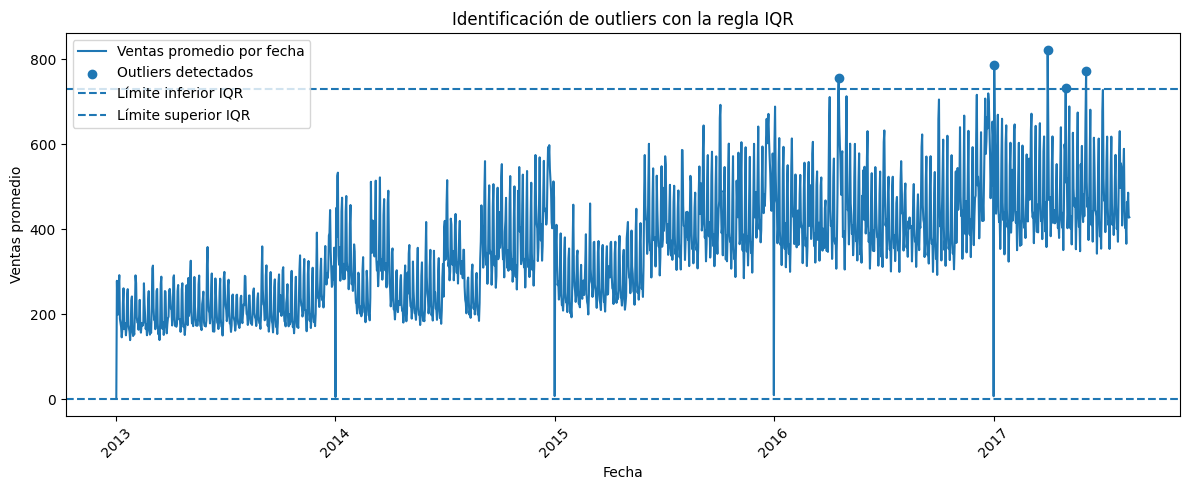

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que date sea fecha
df["date"] = pd.to_datetime(df["date"])

# Serie temporal: promedio de ventas por fecha
ventas_por_fecha = df.groupby("date")["sales"].mean().reset_index()

# Calcular IQR
Q1 = ventas_por_fecha["sales"].quantile(0.25)
Q3 = ventas_por_fecha["sales"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = max(0, Q1 - 1.5 * IQR)
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers
outliers_iqr = ventas_por_fecha[
    (ventas_por_fecha["sales"] < limite_inferior) |
    (ventas_por_fecha["sales"] > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de outliers detectados:", len(outliers_iqr))

# Gráfico
plt.figure(figsize=(12,5))
plt.plot(ventas_por_fecha["date"], ventas_por_fecha["sales"], label="Ventas promedio por fecha")
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["sales"],
    label="Outliers detectados"
)
plt.axhline(limite_inferior, linestyle="--", label="Límite inferior IQR")
plt.axhline(limite_superior, linestyle="--", label="Límite superior IQR")

plt.title("Identificación de outliers con la regla IQR")
plt.xlabel("Fecha")
plt.ylabel("Ventas promedio")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Dado que es una serie temporal, tenemos cuidado en aplicar la detencion en este caso aplicamos el método del rango intercuartílico, como se observa solo se detecto 5 outliers.

Lambda Box-Cox: 0.6334


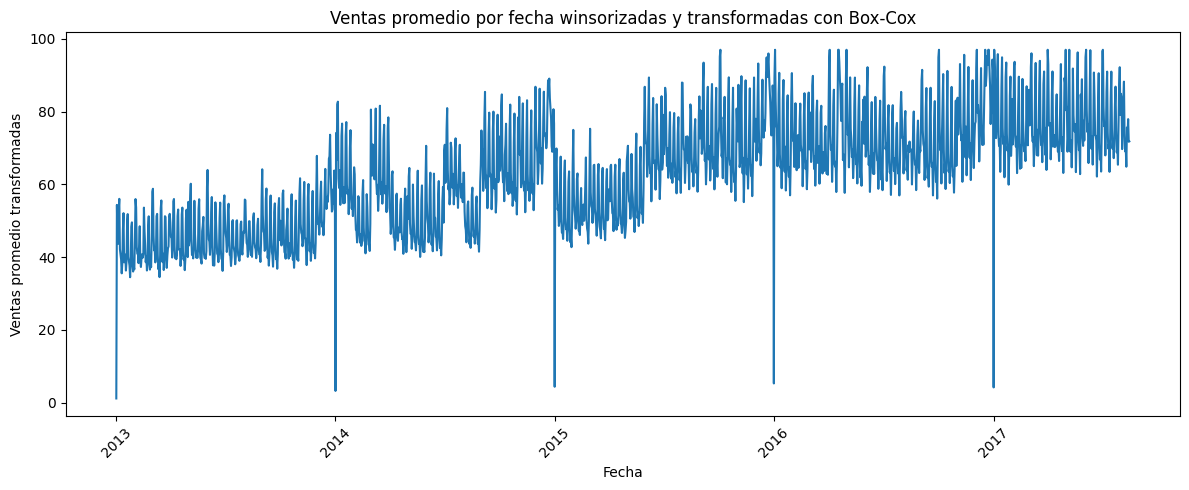

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

# Asegurar formato fecha
df["date"] = pd.to_datetime(df["date"])

# Ventas promedio por fecha
ventas_por_fecha = df.groupby("date")["sales"].mean()

# Winsorización
limite_inferior = 0
limite_superior = ventas_por_fecha.quantile(0.99)

ventas_winsorizadas = ventas_por_fecha.clip(lower=limite_inferior, upper=limite_superior)

# Transformación Box-Cox
ventas_boxcox, lambda_boxcox = boxcox(ventas_winsorizadas + 1)

print(f"Lambda Box-Cox: {lambda_boxcox:.4f}")

# Gráfico solo con la transformación final
plt.figure(figsize=(12,5))
plt.plot(ventas_por_fecha.index, ventas_boxcox)
plt.title("Ventas promedio por fecha winsorizadas y transformadas con Box-Cox")
plt.xlabel("Fecha")
plt.ylabel("Ventas promedio transformadas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Para el tratamiento, primero realizamos una Winsorización y despúes una transformacion de Box-Cox para reducir la influencia de los valores minimos dados al final del año (el cual no es valor atípico ni un error).

ii. Identificación y tratamiento de missing value.

Como se mencionó en el EDA, este conjunto de datos no contiene valores perdidos. Por lo tanto, no fue necesario aplicar técnicas de imputación, eliminación de registros ni tratamientos adicionales asociados a missing values.

3) Ventanas de desarrollo/validación/test:
a. Presenta 2 a 3 métodos de separar (Split) los datos en muestra de entrenamiento, validación y test.

| Método | Descripción | Ventajas / Riesgos |
|---|---|---|
| **Split simple** | Divide los datos en entrenamiento, validación y test. En Python puede implementarse con `scikit-learn`, usando `train_test_split`. | **Ventaja:** simple y fácil de aplicar. **Riesgo:** no sirve para series temporales si se hace de forma aleatoria, ya que puede generar fuga de información. |
| **Validación cruzada** | Divide repetidamente el conjunto de entrenamiento en subconjuntos internos para entrenar y validar varias veces. Puede implementarse con `scikit-learn`, usando `KFold` o `cross_val_score`. | **Ventaja:** entrega una evaluación más robusta. **Riesgo:** en su forma clásica no sirve para series temporales, porque no respeta el orden cronológico. |
| **Rolling windows** | Entrena con un período histórico, valida con un período intermedio y prueba con un período posterior. En Python puede implementarse con `scikit-learn`, usando `TimeSeriesSplit`. | **Ventaja:** sí sirve para series temporales, porque respeta el orden temporal y evita fuga de información. **Riesgo:** su implementación requiere más cuidado. |

Dado que tenemos una serie temporal, optamos por elegir el método Rolling windows del paquete de scikit-learn, donde los porcentajes son
- 70% para entrenamiento
- 20% para validación
- 10% para test

b. Aplica el método seleccionado a su muestra de datos.

Total de observaciones: 1684
Entrenamiento: 1178 (69.95%)
Validación: 337 (20.01%)
Test: 169 (10.04%)


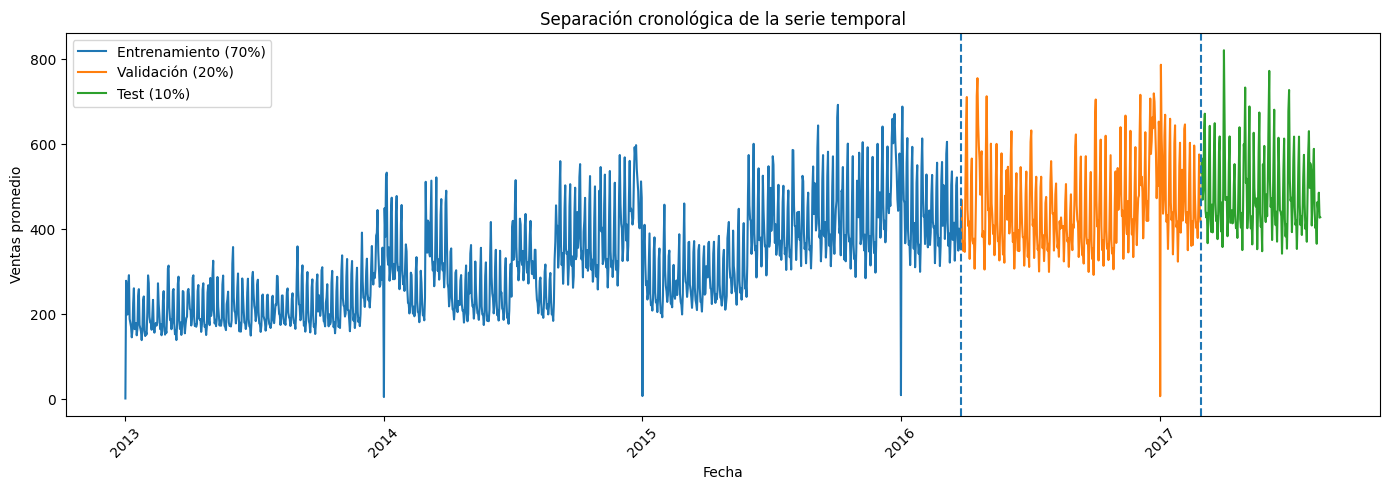

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar formato fecha
df["date"] = pd.to_datetime(df["date"])

# Serie temporal: ventas promedio por fecha
ventas_por_fecha = df.groupby("date")["sales"].mean().reset_index()

# Cantidad total de observaciones
n = len(ventas_por_fecha)

# Índices de corte
train_end = int(n * 0.70)
val_end = int(n * 0.90)

# Separación cronológica
train = ventas_por_fecha.iloc[:train_end]
val = ventas_por_fecha.iloc[train_end:val_end]
test = ventas_por_fecha.iloc[val_end:]

# Ver tamaños
print("Total de observaciones:", n)
print("Entrenamiento:", len(train), f"({len(train)/n:.2%})")
print("Validación:", len(val), f"({len(val)/n:.2%})")
print("Test:", len(test), f"({len(test)/n:.2%})")

# Graficar separación
plt.figure(figsize=(14,5))

plt.plot(train["date"], train["sales"], label="Entrenamiento (70%)")
plt.plot(val["date"], val["sales"], label="Validación (20%)")
plt.plot(test["date"], test["sales"], label="Test (10%)")

# Líneas verticales de corte
plt.axvline(train["date"].iloc[-1], linestyle="--")
plt.axvline(val["date"].iloc[-1], linestyle="--")

plt.title("Separación cronológica de la serie temporal")
plt.xlabel("Fecha")
plt.ylabel("Ventas promedio")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

La serie temporal quedó conformada por un total de 1684 observaciones, las cuales se dividieron cronológicamente en tres subconjuntos, tal como se observa en la gráfica: 1178 observaciones para entrenamiento, 337 para validación y 169 para test. Previamente, los datos fueron sometidos a un proceso de winsorización y posteriormente a una transformación Box-Cox, con el fin de reducir la influencia de valores extremos y estabilizar la variabilidad de la serie. Con ello, los datos quedan adecuadamente preparados y listos para continuar con las siguientes etapas del procesos.

# Conclusiones

1. Dado que la base de datos incluye ventas correspondientes a múltiples familias de productos, el análisis global resulta más complejo y menos determinista, ya que se mezclan patrones de comportamiento distintos dentro de una misma serie. Por ello, un estudio enfocado en una sola familia o en un producto específico permitiría identificar con mayor claridad su patrón temporal, su estacionalidad y la influencia de otros factores sobre las ventas.

2. El análisis exploratorio de datos (EDA) mostró que la base de datos no presenta valores perdidos, lo que constituye una ventaja importante para el estudio. Esto evita la necesidad de aplicar métodos de imputación o eliminación de registros, permitiendo conservar la estructura original de la información y facilitando un análisis más limpio y consistente, acorde con la naturaleza del conjunto de datos.

3. En las series temporales, la separación de los datos en entrenamiento, validación y test no puede realizarse de manera aleatoria, sino que debe respetar el orden cronológico. Esto implica una dificultad adicional respecto a otros tipos de problemas de machine learning, ya que el modelado debe considerar explícitamente la dimensión temporal para evitar fuga de información y lograr una evaluación más realista del desempeño predictivo.

# Bibliografía

- Matplotlib Development Team. (2007). Matplotlib: Visualization with Python. https://matplotlib.org

- McKinney, W. (2010). pandas: Python Data Analysis Library. https://pandas.pydata.org

- NumPy Developers. (2025). NumPy documentation. https://numpy.org

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org

- Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. https://www.statsmodels.org

- Waskom, M. L. (2021). seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://seaborn.pydata.org
